In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import random
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
from torchvision.datasets import KMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  
])
train_dataset_full = KMNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = KMNIST(root='./data', train=False, download=False, transform=transform)

In [12]:
train_size = int(0.75 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

In [14]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)


x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [21]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.num_classes = activation
        self.activation = input_dim
        self.dropout_p = dropout_p
        self.use_batchnorm = use_batchnorm
        self.activation = activation
        
        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU

        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
        
    def get_config(self):
        return {
            'input_dim': self.input_dim,
            'hidden_dims': self.hidden_dims,
            'num_classes': self.num_classes,
            'activation': self.activation,
            'dropout_p': self.dropout_p,
            'use_batchnorm': self.use_batchnorm,
            'activation': self.activation
        }

model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)     

logits: torch.Size([64, 10])


In [33]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "", name1=None, name2=None) -> None:

    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if  name1: plt.savefig(f'artifacts/figures/{name1}.png')
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    if  name2: plt.savefig(f'artifacts/figures/{name2}.png')
    plt.show()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train() 
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [23]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [24]:
def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=6):
    model = make_model()
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

epoch 01/10 | train loss=0.3948, acc=0.8805 | val loss=0.2576, acc=0.9198
epoch 02/10 | train loss=0.1804, acc=0.9454 | val loss=0.1719, acc=0.9461
epoch 03/10 | train loss=0.1326, acc=0.9591 | val loss=0.1292, acc=0.9606
epoch 04/10 | train loss=0.1056, acc=0.9669 | val loss=0.1382, acc=0.9579
epoch 05/10 | train loss=0.0874, acc=0.9721 | val loss=0.1163, acc=0.9646
epoch 06/10 | train loss=0.0725, acc=0.9770 | val loss=0.1074, acc=0.9668
epoch 07/10 | train loss=0.0662, acc=0.9777 | val loss=0.1303, acc=0.9593
epoch 08/10 | train loss=0.0578, acc=0.9818 | val loss=0.1031, acc=0.9728
epoch 09/10 | train loss=0.0534, acc=0.9822 | val loss=0.1250, acc=0.9646
epoch 10/10 | train loss=0.0477, acc=0.9843 | val loss=0.1072, acc=0.9692


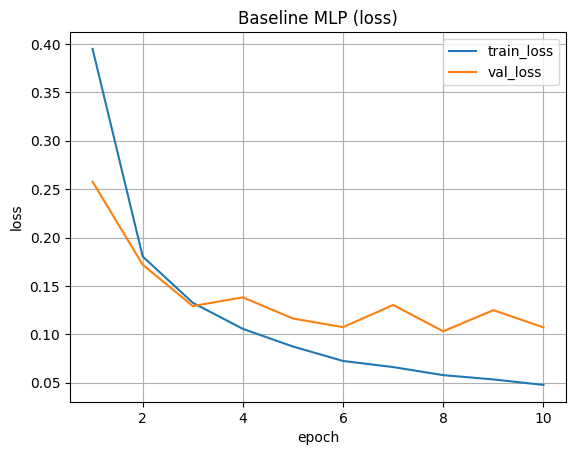

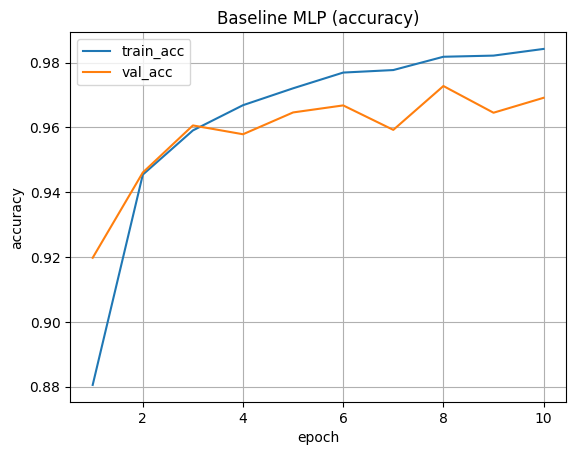

In [34]:
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=0.001)

E1history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=10,
    early_stopping=None
)

plot_history(E1history_baseline, title="Baseline MLP")

In [35]:
baseline.get_config()

{'input_dim': 784,
 'hidden_dims': (256, 128),
 'num_classes': 'relu',
 'activation': 'relu',
 'dropout_p': 0.0,
 'use_batchnorm': False}

epoch 01/10 | train loss=0.4256, acc=0.8695 | val loss=0.2053, acc=0.9356
epoch 02/10 | train loss=0.2094, acc=0.9355 | val loss=0.1761, acc=0.9431
epoch 03/10 | train loss=0.1683, acc=0.9487 | val loss=0.1388, acc=0.9571
epoch 04/10 | train loss=0.1402, acc=0.9573 | val loss=0.1325, acc=0.9595
epoch 05/10 | train loss=0.1234, acc=0.9620 | val loss=0.1171, acc=0.9635
epoch 06/10 | train loss=0.1138, acc=0.9652 | val loss=0.1180, acc=0.9634
epoch 07/10 | train loss=0.1016, acc=0.9688 | val loss=0.1206, acc=0.9656
epoch 08/10 | train loss=0.0933, acc=0.9707 | val loss=0.0968, acc=0.9708
epoch 09/10 | train loss=0.0879, acc=0.9719 | val loss=0.1024, acc=0.9686
epoch 10/10 | train loss=0.0840, acc=0.9733 | val loss=0.1045, acc=0.9700


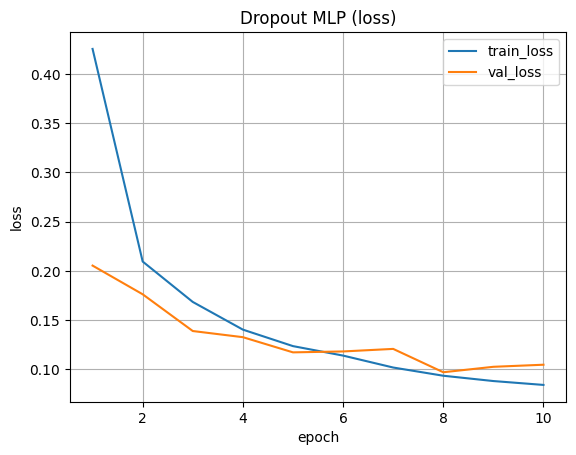

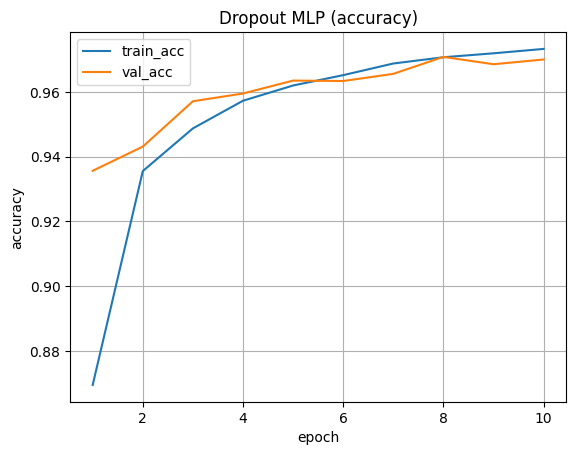

In [36]:
dropout_mlp = MLP(hidden_dims=(256, 128), dropout_p=0.15, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_mlp.parameters(), lr=0.001)

E2dropout_mlp = fit(
    dropout_mlp, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=10,
    early_stopping=None
)

plot_history(E2dropout_mlp, title="Dropout MLP")

epoch 01/10 | train loss=0.2217, acc=0.9311 | val loss=0.1208, acc=0.9637
epoch 02/10 | train loss=0.1131, acc=0.9647 | val loss=0.0989, acc=0.9715
epoch 03/10 | train loss=0.0814, acc=0.9736 | val loss=0.0981, acc=0.9713
epoch 04/10 | train loss=0.0661, acc=0.9794 | val loss=0.0969, acc=0.9720
epoch 05/10 | train loss=0.0585, acc=0.9806 | val loss=0.0945, acc=0.9719
epoch 06/10 | train loss=0.0541, acc=0.9820 | val loss=0.0849, acc=0.9758
epoch 07/10 | train loss=0.0439, acc=0.9854 | val loss=0.0929, acc=0.9737
epoch 08/10 | train loss=0.0409, acc=0.9864 | val loss=0.0854, acc=0.9773
epoch 09/10 | train loss=0.0361, acc=0.9879 | val loss=0.0893, acc=0.9761
epoch 10/10 | train loss=0.0390, acc=0.9882 | val loss=0.0821, acc=0.9795


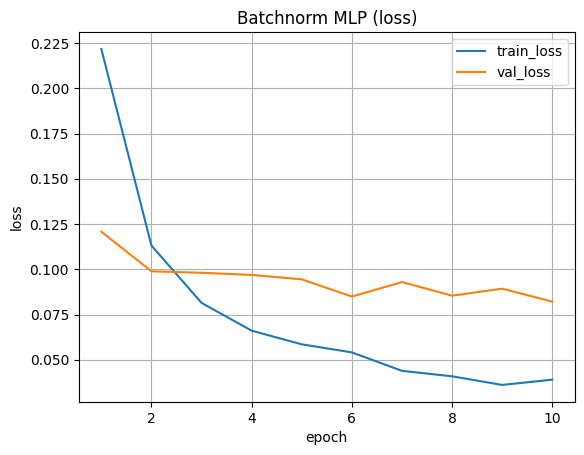

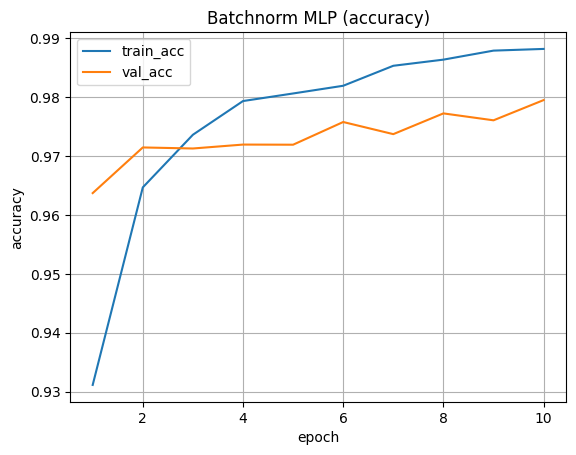

In [37]:
batchnorm_mlp = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(batchnorm_mlp.parameters(), lr=0.01)

E3batchnorm_mlp = fit(
    batchnorm_mlp, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=10,
    early_stopping=None
)

plot_history(E3batchnorm_mlp, title="Batchnorm MLP")

epoch 01/10 | train loss=0.4242, acc=0.8681 | val loss=0.2391, acc=0.9251
epoch 02/10 | train loss=0.2123, acc=0.9357 | val loss=0.1643, acc=0.9493
epoch 03/10 | train loss=0.1627, acc=0.9503 | val loss=0.1292, acc=0.9608
epoch 04/10 | train loss=0.1353, acc=0.9585 | val loss=0.1331, acc=0.9596
epoch 05/10 | train loss=0.1214, acc=0.9619 | val loss=0.1312, acc=0.9601
epoch 06/10 | train loss=0.1129, acc=0.9645 | val loss=0.1070, acc=0.9672
epoch 07/10 | train loss=0.1010, acc=0.9672 | val loss=0.0994, acc=0.9709
epoch 08/10 | train loss=0.0954, acc=0.9702 | val loss=0.1010, acc=0.9707
epoch 09/10 | train loss=0.0862, acc=0.9732 | val loss=0.1041, acc=0.9695
epoch 10/10 | train loss=0.0817, acc=0.9735 | val loss=0.1132, acc=0.9686


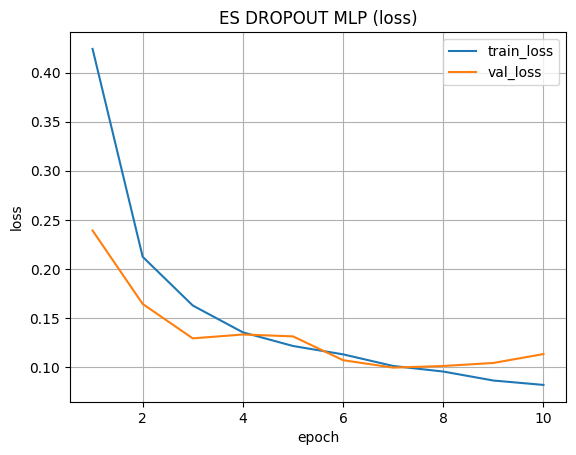

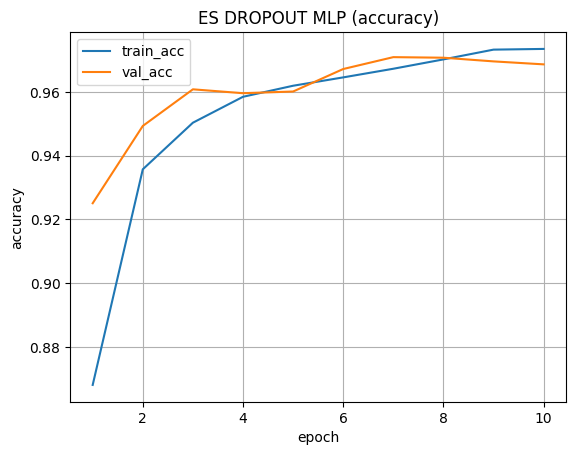

EarlyStopping test: loss=0.1081, acc=0.9689


In [38]:
es_mlp = MLP(hidden_dims=(256, 128), dropout_p=0.15, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(es_mlp.parameters(), lr=0.001)

es = EarlyStopping(patience=4, min_delta=0.0005)

E4es_mlp = fit(
    es_mlp, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=10,
    early_stopping=es
)

plot_history(E4es_mlp, title="ES DROPOUT MLP",name1="curves_best")
test_lossE4, test_accE4 = evaluate(es_mlp, test_loader, criterion, device)
print(f"EarlyStopping test: loss={test_lossE4:.4f}, acc={test_accE4:.4f}")

In [39]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 4  

def make_model():
    return MLP().to(device)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

epoch 01/4 | train loss=5.3417, acc=0.1040 | val loss=2.3059, acc=0.0992
epoch 02/4 | train loss=2.3092, acc=0.1046 | val loss=2.3105, acc=0.1125
epoch 03/4 | train loss=2.3108, acc=0.1024 | val loss=2.3052, acc=0.0992
epoch 04/4 | train loss=2.3104, acc=0.1029 | val loss=2.3126, acc=0.0967


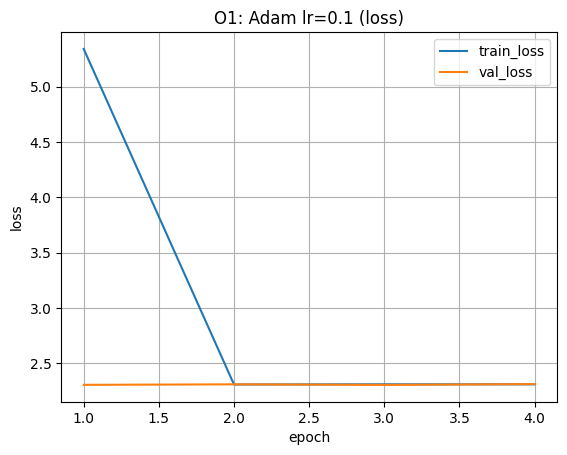

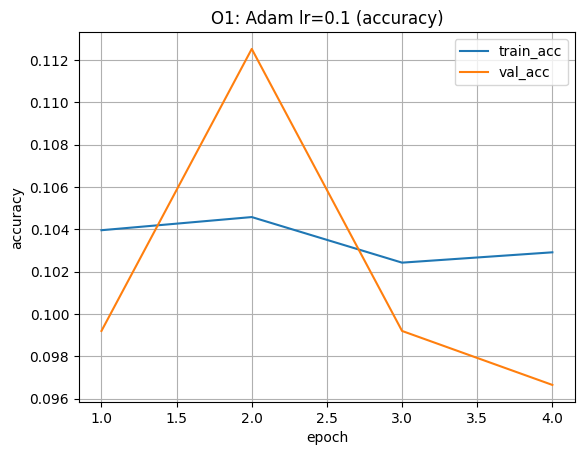

In [40]:
O1model = MLP(hidden_dims=(256, 128), dropout_p=0.15, use_batchnorm=False).to(device)
O1opt = make_optimizer(O1model, kind="adam", lr=0.1, weight_decay=0.0)

criterion = nn.CrossEntropyLoss()
es = EarlyStopping(patience=4, min_delta=0.0005)

O1_mlp = fit(
    O1model, train_loader, val_loader,
    O1opt, criterion, device,
    epochs=EPOCHS,
    early_stopping=es
)
plot_history(O1_mlp, title="O1: Adam lr=0.1")

epoch 01/4 | train loss=2.3028, acc=0.1096 | val loss=2.3011, acc=0.1068
epoch 02/4 | train loss=2.3023, acc=0.1120 | val loss=2.3011, acc=0.1068
epoch 03/4 | train loss=2.3027, acc=0.1123 | val loss=2.3011, acc=0.1068
epoch 04/4 | train loss=2.3027, acc=0.1121 | val loss=2.3011, acc=0.1068


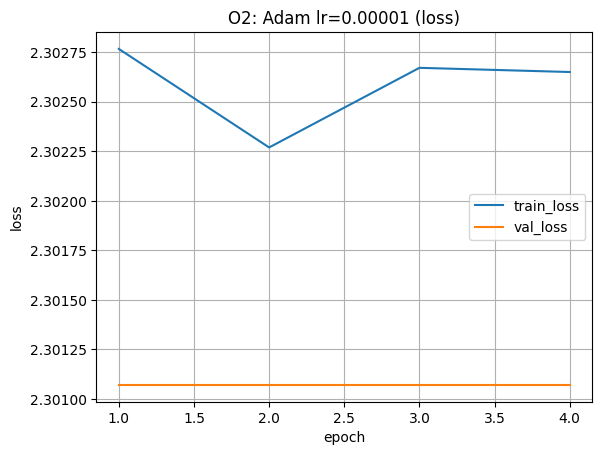

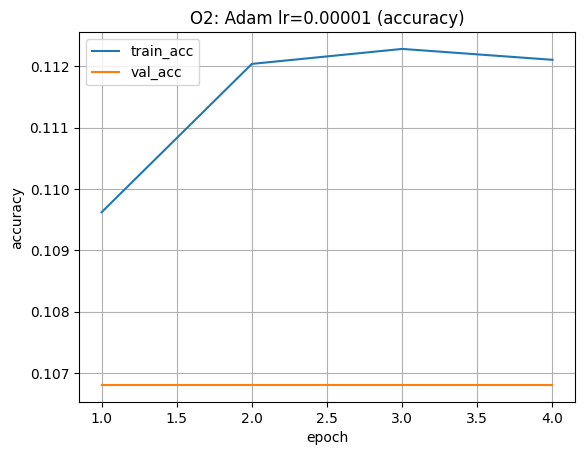

In [41]:
O2model = MLP(hidden_dims=(256, 128), dropout_p=0.15, use_batchnorm=False).to(device)
O2opt = make_optimizer(O1model, kind="adam", lr=0.00001, weight_decay=0.0)

criterion = nn.CrossEntropyLoss()
es = EarlyStopping(patience=4, min_delta=0.0005)

O2_mlp = fit(
    O2model, train_loader, val_loader,
    O2opt, criterion, device,
    epochs=EPOCHS,
    early_stopping=es
)
plot_history(O2_mlp, title="O2: Adam lr=0.00001")

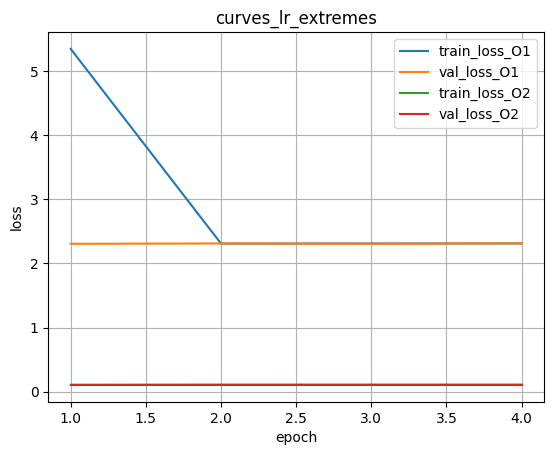

In [42]:
epochs = np.arange(1, len(O1_mlp["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, O1_mlp["train_loss"], label="train_loss_O1")
plt.plot(epochs, O1_mlp["val_loss"], label="val_loss_O1")
plt.plot(epochs, O2_mlp["train_acc"], label="train_loss_O2")
plt.plot(epochs, O2_mlp["val_acc"], label="val_loss_O2")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("curves_lr_extremes")
plt.legend()
plt.grid(True)
plt.savefig(f'artifacts/figures/curves_lr_extremes.png')
plt.show()

epoch 01/15 | train loss=1.2898, acc=0.6285 | val loss=0.5369, acc=0.8594
epoch 02/15 | train loss=0.4895, acc=0.8568 | val loss=0.3822, acc=0.8873
epoch 03/15 | train loss=0.3910, acc=0.8833 | val loss=0.3317, acc=0.9020
epoch 04/15 | train loss=0.3461, acc=0.8985 | val loss=0.3015, acc=0.9098
epoch 05/15 | train loss=0.3129, acc=0.9076 | val loss=0.2751, acc=0.9188
epoch 06/15 | train loss=0.2858, acc=0.9146 | val loss=0.2581, acc=0.9225
epoch 07/15 | train loss=0.2642, acc=0.9212 | val loss=0.2392, acc=0.9298
epoch 08/15 | train loss=0.2442, acc=0.9284 | val loss=0.2214, acc=0.9346
epoch 09/15 | train loss=0.2293, acc=0.9320 | val loss=0.2121, acc=0.9385
epoch 10/15 | train loss=0.2142, acc=0.9361 | val loss=0.1977, acc=0.9419
epoch 11/15 | train loss=0.2018, acc=0.9410 | val loss=0.1839, acc=0.9456
epoch 12/15 | train loss=0.1916, acc=0.9440 | val loss=0.1759, acc=0.9469
epoch 13/15 | train loss=0.1765, acc=0.9477 | val loss=0.1677, acc=0.9506
epoch 14/15 | train loss=0.1720, acc=0

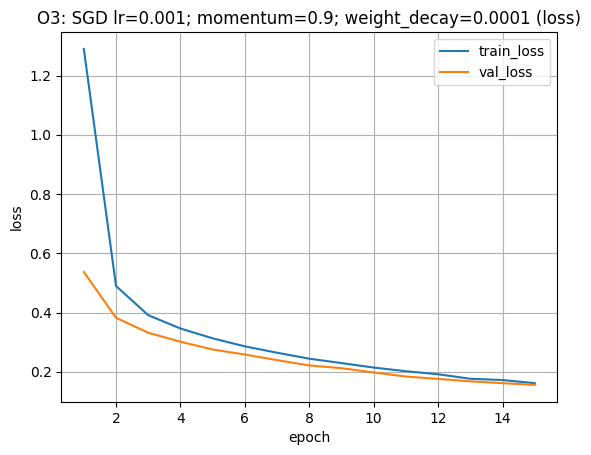

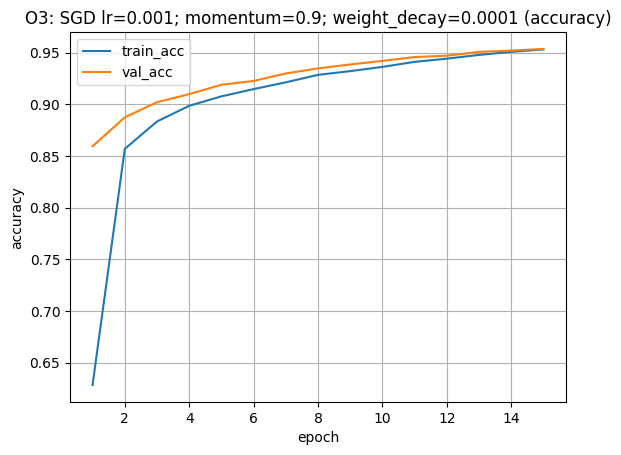

EarlyStopping test: loss=0.1408, acc=0.9580


In [43]:
O3model = MLP(hidden_dims=(256, 128), dropout_p=0.15, use_batchnorm=False).to(device)
O3opt = make_optimizer(O3model, kind="sgd", lr=0.001, weight_decay=0.0001)

criterion = nn.CrossEntropyLoss()
es = EarlyStopping(patience=4, min_delta=0.0005)

O3_mlp = fit(
    O3model, train_loader, val_loader,
    O3opt, criterion, device,
    epochs=15,
    early_stopping=es
)
plot_history(O3_mlp, title="O3: SGD lr=0.001; momentum=0.9; weight_decay=0.0001")


test_lossO3, test_accO3 = evaluate(O3model, test_loader, criterion, device)
print(f"EarlyStopping test: loss={test_lossO3:.4f}, acc={test_accO3:.4f}")

In [46]:
import pandas as pd


In [44]:
torch.save(es_mlp.state_dict(), "artifacts/best_model.pt")

In [47]:
runs_pd = pd.DataFrame(columns=["experiment_id",
                                "dataset",
                                "seed",
                                "model_summary",
                                "optimizer",
                                "lr",
                                "momentum",
                                "weight_decay",
                                "epochs_trained",
                                "best_val_accuracy",
                                "best_val_loss"])

In [48]:
import json
all_models_additional = {"seed":42, "dataset":"KMNIST", 
                         "optimizer":"Adam", "momentum":0, "weight_decay":0, 
                         "epochs_trained":10,"lr":1e-3}

best_model_config = {"experiment_id":"E4",**all_models_additional, 
                     **es_mlp.get_config(),
                     "best_val_loss":float(np.nanmax(E4es_mlp["val_loss"])) if len(E4es_mlp["val_loss"]) else float("nan"), 
                     "best_val_accuracy": float(np.nanmax(E4es_mlp["val_acc"])) if len(E4es_mlp["val_acc"]) else float("nan"),
                     "model_summary":str(es_mlp)}

with open('artifacts/best_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_model_config, f, ensure_ascii=False, indent=4)

In [49]:
E1_config = {"experiment_id":"E1",**all_models_additional, 
             **baseline.get_config(),
             "best_val_loss": float(np.nanmax(E1history_baseline["val_loss"])) if len(E1history_baseline["val_loss"]) else float("nan"), 
             "best_val_accuracy": float(np.nanmax(E1history_baseline["val_acc"])) if len(E1history_baseline["val_acc"]) else float("nan"),
             "model_summary":str(baseline)}

E2_config = {"experiment_id":"E2",**all_models_additional, 
             **dropout_mlp.get_config(),
             "best_val_loss": float(np.nanmax(E2dropout_mlp["val_loss"])) if len(E2dropout_mlp["val_loss"]) else float("nan"), 
             "best_val_accuracy":float(np.nanmax(E2dropout_mlp["val_acc"])) if len(E2dropout_mlp["val_acc"]) else float("nan"),
             "model_summary":str(dropout_mlp)}

E3_config = {"experiment_id":"E3",**all_models_additional, 
             **batchnorm_mlp.get_config(),
             "best_val_loss":float(np.nanmax(E3batchnorm_mlp["val_loss"])) if len(E3batchnorm_mlp["val_loss"]) else float("nan"), 
             "best_val_accuracy": float(np.nanmax(E3batchnorm_mlp["val_acc"])) if len(E3batchnorm_mlp["val_acc"]) else float("nan"),
             "model_summary":str(batchnorm_mlp)}

In [50]:
O1_config = {
            "experiment_id":"O1",
             **O1model.get_config(),
            "best_val_loss":float(np.nanmax(O1_mlp["val_loss"])) if len(O1_mlp["val_loss"]) else float("nan"), 
             "best_val_accuracy":float(np.nanmax(O1_mlp["val_acc"])) if len(O1_mlp["val_acc"]) else float("nan"), 
            "model_summary":str(O1model),
             "seed":42, 
            "dataset":"KMNIST", 
            "optimizer":"Adam",
            "momentum":0, 
            "weight_decay":0, 
            "epochs_trained":6,
            "lr":1e-1,
}

O2_config = {
            "experiment_id":"O2",
             **O2model.get_config(),
            "best_val_loss":float(np.nanmax(O2_mlp["val_loss"])) if len(O2_mlp["val_loss"]) else float("nan"), 
             "best_val_accuracy":float(np.nanmax(O2_mlp["val_acc"])) if len(O2_mlp["val_acc"]) else float("nan"), 
            "model_summary":str(O2model),
             "seed":42, 
            "dataset":"KMNIST", 
            "optimizer":"Adam",
            "momentum":0, 
            "weight_decay":0, 
            "epochs_trained":6,
            "lr":1e-5,
}
O3_config = {
            "experiment_id":"O3",
             **O3model.get_config(),
            "best_val_loss":float(np.nanmax(O3_mlp["val_loss"])) if len(O3_mlp["val_loss"]) else float("nan"), 
             "best_val_accuracy":float(np.nanmax(O3_mlp["val_acc"])) if len(O3_mlp["val_acc"]) else float("nan"), 
             "model_summary":str(O3model),
             "seed":42, 
            "dataset":"KMNIST", 
            "optimizer":"SGD",
            "momentum":0.9, 
            "weight_decay":1e-4, 
            "epochs_trained":15,
            "lr":1e-3,
}

In [51]:
runs_pd.loc[0] = E1_config
runs_pd.loc[1] = E2_config
runs_pd.loc[2] = E3_config
runs_pd.loc[3] = best_model_config
runs_pd.loc[4] = O1_config
runs_pd.loc[5] = O2_config
runs_pd.loc[6] = O3_config
runs_pd

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,KMNIST,42,MLP(\n (net): Sequential(\n (0): Flatten(s...,Adam,0.00100,0.0,0.0000,10,0.972806,0.257647
1,E2,KMNIST,42,MLP(\n (net): Sequential(\n (0): Flatten(s...,Adam,0.00100,0.0,0.0000,10,0.970811,0.205292
2,E3,KMNIST,42,MLP(\n (net): Sequential(\n (0): Flatten(s...,Adam,0.00100,0.0,0.0000,10,0.979521,0.120753
3,E4,KMNIST,42,MLP(\n (net): Sequential(\n (0): Flatten(s...,Adam,0.00100,0.0,0.0000,10,0.970878,0.239086
4,O1,KMNIST,42,MLP(\n (net): Sequential(\n (0): Flatten(s...,Adam,0.10000,0.0,0.0000,6,0.112522,2.312600
5,O2,KMNIST,42,MLP(\n (net): Sequential(\n (0): Flatten(s...,Adam,0.00001,0.0,0.0000,6,0.106804,2.301071
6,O3,KMNIST,42,MLP(\n (net): Sequential(\n (0): Flatten(s...,SGD,0.00100,0.9,0.0001,15,0.953480,0.536920


In [52]:
runs_pd.to_csv("artifacts/runs.csv")